(Optional) — You can enable text wrapping in code blocks for better readability, especially when working with long prompts.

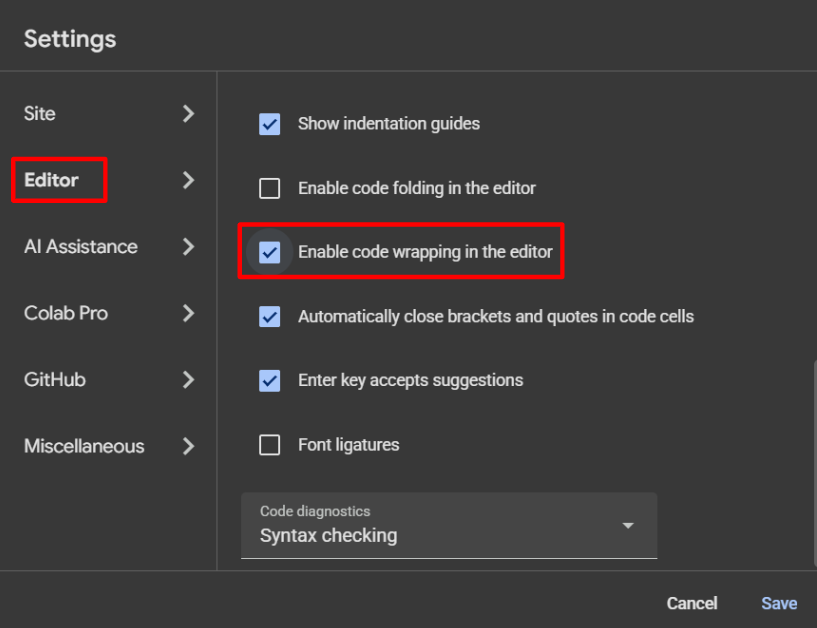

(Optional) — Run the code below to enable text wrapping in the output block for better readability.

In [ ]:
from IPython.display import HTML, display, Image

def set_css():
  display(HTML('''
  <style>
    pre {
        white-space: pre-wrap;
    }
  </style>
  '''))
get_ipython().events.register('pre_run_cell', set_css)

In [ ]:
%%capture
!pip -q install langchain-core langchain-community langgraph langchain_google_genai duckduckgo-search

!pip install -U ddgs

- Set API Key and the model

In [ ]:
import os
from getpass import getpass

# Read your API key from the environment variable or set it manually
api_key = getpass("GEMINI_API_KEY :")

GEMINI_API_KEY :··········


In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Create LLM
llm = ChatGoogleGenerativeAI(
    model= "gemini-2.5-flash",
    temperature=1.0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    google_api_key=api_key,
)

# Basic LangGraph
When using LangGraph, we mainly think about five core components:

1. Node – the logic or processor
2. Entry Point – the starting point (which node the process begins with)
3. Edge – the connection between nodes, representing the workflow
4. State
   - the data structure that is passed between nodes
   - may or may not collect historical memory (Stateful vs. Stateless)
5. Condition (Conditional Edge) – determines whether the process should end or continue


## Ex.1 Hello Graph — single node

Task: Take input text and say hello to it

- Entry Point: input starts at node **echo**
- Node: only one processor (**echo**) → adds “Hello” to the input
- Condition: none → No Conditional Edge
- Edge:
  - Direct: echo → END (finish immediately)
- State: {"text": ...}
  - carries only one field
  - no memory (stateless) → each node overwrites the state

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

# ----- State -----
class EchoState(TypedDict):
    text: str

# ----- Single node: just transforms the text -----
def echo(state: EchoState):
    return {"text": f"Hello, {state['text']}!"} # return state {..}

# ----- Build the graph -----
g1 = StateGraph(EchoState)
g1.add_node("echo", echo)
g1.set_entry_point("echo")
g1.add_edge("echo", END)
app1 = g1.compile()


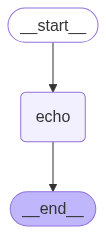

In [ ]:

Image(app1.get_graph().draw_mermaid_png(max_retries=10))

In [ ]:
# ----- Run -----
print(app1.invoke({"text": "LangGraph beginner"})) # latest state is printed out

{'text': 'Hello, LangGraph beginner!'}


## Ex.2 Two Nodes

Task: Transform input text by first adding a prefix, then a suffix

- Node:
  - Node A: add a prefix to the input text
  - Node B: add a suffix to the result from Node A
- Entry Point: input starts at **Node A**
- Condition: none → No conditional edge
- Edge:
  - Direct: A → B → END (straight line)
- State:
  - Node A writes `text` → updates state
  - Node B reads `text` from state (output of Node A) → processes → overwrites state
- Flow: always goes A → B

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

# ----- State -----
class ABState(TypedDict):
    text: str  # overwrite, not append (no historical memory)

# ----- Node -----
def node_a(state: ABState): # node A can access ABstate
    # Add prefix
    return {"text": f"[prefix added] {state['text']}"} # return state {..}

def node_b(state: ABState): # node B can access ABstate
    # Add suffix
    return {"text": state["text"] + " [suffix added]"} # return state {..}

# ABstate is shared across node_a and node_b.


g2 = StateGraph(ABState)
g2.add_node("A", node_a)
g2.add_node("B", node_b)

g2.set_entry_point("A")     # start at A
g2.add_edge("A", "B")       # then go to B
g2.add_edge("B", END)       # end after B
app2 = g2.compile()

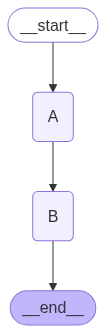

In [ ]:
Image(app2.get_graph().draw_mermaid_png(max_retries=10))

In [ ]:
print(app2.invoke({"text": "input text"}))

{'text': '[prefix added] input text [suffix added]'}


## Ex.3 Stateless vs. Stateful

Up to this point, our examples have been **stateless** (the value gets overwritten each time):
```
class State(TypedDict):
    text: str
```
We can switch to a **stateful** design simply like this:
```
class State(TypedDict):
    text: Annotated[List[str], add]
```

Here, instead of overwriting, each node appends its output to a list of `text`.

Alternatively, you can also use one of the **pre-built state management classes** provided by LangGraph, which can simplify handling common patterns (e.g., appending, accumulating messages, or managing conversation history).

For more details, see the official documentation:
https://python.langchain.com/docs/how_to/message_history/


- Stateless Example

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

class StateLess(TypedDict):
    text: str  # here

def nodeA(state: StateLess):
    return {"text": "I am node A."} # return state {..}

def nodeB(state: StateLess):
    return {"text": "I am node B."} # return state {..}

def final(state: StateLess):
    return {"text": f"Final state: {state['text']}"} # return state {..}

g31 = StateGraph(StateLess)
g31.set_entry_point("A")
g31.add_node("A", nodeA)
g31.add_node("B", nodeB)
g31.add_node("final", final)

g31.add_edge("A", "B")
g31.add_edge("B", "final")
g31.add_edge("final", END)

app_stateless = g31.compile()

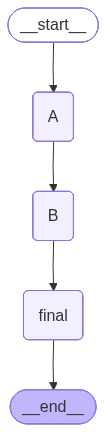

In [ ]:
Image(app_stateless.get_graph().draw_mermaid_png(max_retries=10))

In [ ]:
print(app_stateless.invoke({"text": ""})["text"])

Final state: I am node B.


> Only the state from Node B is printed out (the state from Node A is overwritten).


- Stateful Example

In [ ]:
from typing import TypedDict, List, Annotated
from langgraph.graph import StateGraph, END
from operator import add

class StateFul(TypedDict):
    text: Annotated[List[str], add]  # here : automatically appends new state/ not overwrite

def nodeA(state: StateFul):
    return {"text": ["I am node A."]} # return state {..}

def nodeB(state: StateFul):
    return {"text": ["I am node B."]} # return state {..}

def final(state: StateFul):
    return {"text": [f"Final state: {state['text']}"]} # return state {..}

g32 = StateGraph(StateFul)
g32.set_entry_point("A")
g32.add_node("A", nodeA)
g32.add_node("B", nodeB)
g32.add_node("final", final)

g32.add_edge("A", "B")
g32.add_edge("B", "final")
g32.add_edge("final", END)

app_stateful = g32.compile()

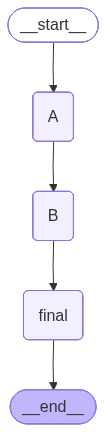

In [ ]:
Image(app_stateful.get_graph().draw_mermaid_png(max_retries=10))

In [ ]:
print(app_stateful.invoke({"text": []})["text"][-1]) # latest state contains all previous states (stateful)

Final state: ['I am node A.', 'I am node B.']


> All previous states are automatically appended to the list.  
The final state contains all previous states, as shown.

## Ex.4 Condition (Router)

Task: Build an AI that answers questions, but does not answer political ones

Nodes:
  - LLM Classifier
  - Rule-based Answer (for political question)
  - LLM Answer (for non-polical question)

Entry Point: LLM Classifier

Edges:
  - Conditional Edge (Router):
    - if `is_politic = true`:
        Router → Rule-based Answer
    - if `is_politic = false`:
        Router → LLM Answer
  - Direct Edge:
    - Rule-based Answer → END
    - LLM Answer → END

State: Stateless (no in-memory history required)


In [ ]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI

# Define LLMs
llm_moderator = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    google_api_key=api_key,
)

llm_answer = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.2,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    google_api_key=api_key,
)

# Define State
class BlockState(TypedDict):
    text: str        # user input, stateless
    is_politic: bool # classifier output

# Define Nodes
def classifier_node(state: BlockState):
    """
    Use the moderator LLM to classify whether the input text is political or not.
    Update 'is_politic' in the state.
    """
    user_text = state["text"]
    sys_prompt = (
        "You are a strict text classifier. "
        "Task: Decide if the user's text is about POLITICS (governments, elections, public policy, "
        "political parties, politicians, geopolitics). "
        "Reply with exactly one token: TRUE or FALSE."
    )
    msg = f"Text: {user_text}\nAnswer (TRUE/FALSE only):"
    out = llm_moderator.invoke(
        [{"role": "system", "content": sys_prompt},
         {"role": "user", "content": msg}]
    ).content.strip().upper()

    is_politic = out.startswith("T")  # TRUE -> political
    return {"is_politic": is_politic}

def llm_answer_node(state: BlockState):
    """
    If not political → generate an answer using the answering LLM.
    """
    prompt = f"Answer the user's question/help politely and concisely:\n\nUSER: {state['text']}"
    ans = llm_answer.invoke(prompt).content
    return {"text": ans}

def block_rule_node(state: BlockState):
    """
    If political → return a rule-based block message.
    """
    blocked_msg = (
        "Sorry, this content is related to politics, so I cannot provide an answer here. "
        "Please adjust your question to be non-political and try again."
    )
    return {"text": blocked_msg}

# Router (Conditional Function)
def should_allow_or_block(state: BlockState) -> Literal["allow", "block"]:
    return "block" if state.get("is_politic", False) else "allow"

# Build Graph
g = StateGraph(BlockState)
g.set_entry_point("classifier")
g.add_node("classifier", classifier_node)
g.add_node("llm_answer", llm_answer_node)
g.add_node("block_rule", block_rule_node)

g.add_conditional_edges(
    "classifier",
    should_allow_or_block,
    {
        "allow": "llm_answer",  # not political → answer with LLM (defined as `allow` path)
        "block": "block_rule",  # political → block with rule-based reply (defined as `block` path)
    },
)

g.add_edge("llm_answer", END)
g.add_edge("block_rule", END)

app_llm_no_political_talking = g.compile()

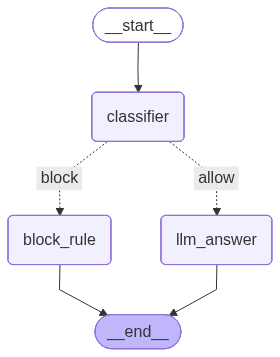

In [ ]:
Image(app_llm_no_political_talking.get_graph().draw_mermaid_png(max_retries=10))

In [ ]:
input = {"text": "Who will win the next election in Thailand?"}
print(f"User's query: {input}")
print('--'*40)
for state in app_llm_no_political_talking.stream(input, stream_mode="updates"):
    for node, update in state.items():
      print(f"['Node : '{node}] -> 'Result : '{update}")

User's query: {'text': 'Who will win the next election in Thailand?'}
--------------------------------------------------------------------------------
['Node : 'classifier] -> 'Result : '{'is_politic': True}
['Node : 'block_rule] -> 'Result : '{'text': 'Sorry, this content is related to politics, so I cannot provide an answer here. Please adjust your question to be non-political and try again.'}


In [ ]:
input = {"text": "How does photosynthesis work?"}
print(f"User's query: {input}")
print('--'*40)
for state in app_llm_no_political_talking.stream(input, stream_mode="updates"):
    for node, update in state.items():
      print(f"['Node : '{node}] -> 'Result : '{update}")

User's query: {'text': 'How does photosynthesis work?'}
--------------------------------------------------------------------------------
['Node : 'classifier] -> 'Result : '{'is_politic': False}
['Node : 'llm_answer] -> 'Result : '{'text': "Photosynthesis is the process plants and other organisms use to convert light energy into chemical energy (food).\n\nHere's a simplified breakdown:\n1.  **Ingredients:** Plants absorb **sunlight** (using chlorophyll), **water** (from roots), and **carbon dioxide** (from the air).\n2.  **Conversion:** Inside specialized cells, the light energy is used to convert water and carbon dioxide into **glucose** (a sugar, their food).\n3.  **Byproduct:** **Oxygen** is released as a byproduct into the atmosphere.\n\nEssentially, it turns light, water, and CO2 into plant food and the oxygen we breathe."}


# ReAct (Thought + Tool Calling + Observe)

ReACT (Reasoning and Acting) Agents are AI systems that combine reasoning capabilities of LLMs with action execution, enabling them to iteratively think through problems, use tools, and act based on observations to achieve the user goals.

The ReAct pattern was first introduced in the [“ReAct: Synergizing Reasoning and Acting in Language Models”](https://arxiv.org/abs/2210.03629) in 2023. It was inspired by how humans plan and solve complex tasks, rather than implementing predefined workflows. ReAct agents rely on the LLM's reasoning capabilities to dynamically adjust their actions based on new information or the results of previous steps.

ReACT Agents have gained traction due to their ability to handle complex tasks by breaking them into manageable reasoning steps and leveraging external tools.

![react.png](https://github.com/philschmid/gemini-samples/blob/main/assets/react.png?raw=1)

The ReAct agent:

1. Takes a user **query** as input
2. Reasons about the query and decides on an action
3. Executes the chosen action using available tools
4. Observes the result of the action
5. Repeats steps until it can provide a final answer

This part modified from :
- https://langchain-ai.github.io/langgraph/how-tos/react-agent-from-scratch/#define-the-graph
- https://colab.research.google.com/drive/14ncV0nviLcP9IDzmFSRGSXb7Bgpz212v?usp=sharing

## States

In [ ]:
from typing import TypedDict, List, Annotated
from typing_extensions import NotRequired
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from operator import add

class OverallState(TypedDict):
    messages: Annotated[list[BaseMessage], add] # Stateful : Memorize all previous states
    query: str

Note: For this example, we use `BaseMessage` as the data type for our state.  

`BaseMessage` is the abstract class of `HumanMessage`, `AIMessage`, and `SystemMessage`.  
You can think of it like a `string`, but with extra information:  
- it keeps track of the **role** (human, AI, system)  
- it can also store **metadata** (e.g., tool calls, token usage, etc.)  

This makes it more suitable than plain strings when building multi-turn conversations or agents with LangGraph and better for downstream tasks.


In [ ]:
llm.invoke('Hello') # response = AIMessage()

AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--4ead650c-9c51-401d-9222-85a2ab0ffac3-0', usage_metadata={'input_tokens': 2, 'output_tokens': 298, 'total_tokens': 300, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 289}})

## Nodes

### Define Tools

In [ ]:
# Tool 1
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# Tool 2
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

# Tool 3
def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [ ]:
!pip -q install yahoo-finance

  Preparing metadata (setup.py) ... done


In [ ]:
import yfinance as yf

# Tool 4
def get_stock_price(ticker: str) -> float:
    """Gets a stock price from Yahoo Finance.

    Args:
        ticker: ticker str
    """
    # """This is a tool for getting the price of a stock when passed a ticker symbol"""
    stock = yf.Ticker(ticker)
    return stock.info['previousClose']

In [ ]:
get_stock_price("AAPL") # tool test

229.72

In [ ]:
# Tool 5
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

search.invoke("How old is Brad Pitt?") # test search function

"William Bradley Pitt (born December 18, 1963) is an American actor and film producer. In a film career spanning more than thirty years, Pitt has received numerous accolades, including two … Jun 24, 2025 — Brad Pitt is back on the big screen with his latest movie but the now 61-year-old is showing off a striking transformation. Jun 25, 2025 — Today, 61-year-old Brad Pitt is a new man, happily dating 32-year-old Ines de Ramon—who just appeared with him at the London premiere of F1, Pitt's new film ... May 23, 2025 — The 61-year-old Hollywood actor has returned to his Los Angeles home where he resides with the 32-year-old jewelry executive, DailyMail.com has learned. Hard to believe he's 61 years old … 😳 It is not just about nutritions and sport and plastic surgeries, guys."

### Define Nodes

- We need to define two nodes to build ReAct: `ToolNode` and `LLM bound with tools` node  
  - Bound LLM = reasoner + observer in one  
    • As Reasoner → decides which tool to call and generates the tool call message  
    • As Observer → receives the tool result and decides whether to call another tool or finish  
    • Implemented with `llm.bind_tools`  

  - ToolNode = executes tool calls and returns results to the state  
    • Implemented with `ToolNode(tools)` where `tools` is the list of tool functions defined earlier


#### Tool Node

In [ ]:
from langgraph.prebuilt import ToolNode
tools = [add, multiply, divide, search, get_stock_price] # list of defined tools

# Define Tool Node
tool_node = ToolNode(tools)

# ToolNode helps us parse the LLM’s tool-calling output, execute the corresponding tool function, and store the result back into the state.

#### LLM Node

In [ ]:
llm = ChatGoogleGenerativeAI(
    model= "gemini-2.5-flash",
    temperature=1.0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    google_api_key=api_key,
)

llm_with_tools = llm.bind_tools(tools) # tools = [add, multiply, ....]

# with llm.bind_tools -> LLM = Reasoner + Observer combined
  # Reasoner → LLM decides which tool to call
  # Observer → LLM consumes the tool output and continues reasoning

- Inspect `llm_with_tools`'s response

In [ ]:
llm_with_tools.invoke('2+2=') # inspect response from LLM with tools

AIMessage(content='', additional_kwargs={'function_call': {'name': 'add', 'arguments': '{"a": 2.0, "b": 2.0}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--51d3ecb9-b4ed-47af-b398-33779b0a89eb-0', tool_calls=[{'name': 'add', 'args': {'a': 2.0, 'b': 2.0}, 'id': 'ba142e8b-054b-4268-be82-c4e9507d0cfa', 'type': 'tool_call'}], usage_metadata={'input_tokens': 257, 'output_tokens': 74, 'total_tokens': 331, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 56}})

The response contains ```tool_calls=[{'name': 'add', 'args': {'a': 2.0, 'b': 2.0}``` (function name and argument for the function).

In [ ]:
llm_with_tools.invoke("today's temperature") # inspect response from LLM with tools

AIMessage(content='I cannot tell you the temperature. I do not have access to real-time weather data.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--3c6d06f7-e92e-49b2-b638-878c9d62881d-0', usage_metadata={'input_tokens': 257, 'output_tokens': 129, 'total_tokens': 386, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 110}})

For this case, the response doesn't contain a`tool_calls` field.

> Keep in mind: we will use the existence of `tool_calls` as the routing condition.


In [ ]:
# Define LLM Node
from langchain_core.messages import HumanMessage, SystemMessage

def reasoner(state: OverallState):
    sys_msg = [SystemMessage(content="You are a helpful assistant.")]
    hist_msg = state['messages'] # reasoner see all messages in the memory

    inputs = sys_msg + hist_msg

    return {"messages": [llm_with_tools.invoke(inputs)]}


## Conditional Edge

Condition:  
- If the LLM makes a tool call (`tool_calls = true`) → return "continue"  
- If the LLM does not make a tool call (`tool_calls = false`) → return "end"


In [ ]:
# Define the conditional edge that determines whether to continue or not
def tool_condition(state: OverallState):
    messages = state["messages"]
    # If the last message is not a tool call, then we finish
    if not messages[-1].tool_calls:
        return "end"
    # Otherwise if there is, we continue
    return "continue"

## Build a Graph

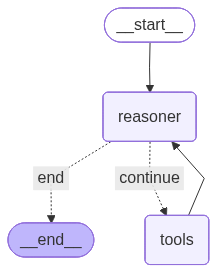

In [ ]:
from langgraph.graph import START, StateGraph, END
from IPython.display import Image, display

# Graph
builder = StateGraph(OverallState)

# Add nodes
builder.add_node("reasoner", reasoner) ## llm binded with tools
builder.add_node("tools", tool_node)


# Add edges
builder.set_entry_point("reasoner")
builder.add_conditional_edges(
    "reasoner",
    tool_condition,
    {"continue": "tools",
     "end": END}
)
builder.add_edge("tools", "reasoner")
react_graph = builder.compile()

# Display the graph
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [ ]:
response = react_graph.invoke({"messages":[ HumanMessage(content="What is 2 times Brad Pitt's age?")]})

In [ ]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 times Brad Pitt's age?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (6bee0868-6cfe-4c32-9642-df2bdd6e04f8)
 Call ID: 6bee0868-6cfe-4c32-9642-df2bdd6e04f8
  Args:
    query: Brad Pitt's age
================================= Tool Message =================================
Name: duckduckgo_search

1 day ago - William Bradley Pitt ( born December 18, 1963 ) is an American actor and film producer. In a film career spanning more than thirty years, Pitt has received numerous accolades, including two Academy Awards, two British Academy Film Awards, two Golden Globe Awards, and a Primetime Emmy Award. 2 days ago - Brad Pitt is an Ecuadorian actor and film producer. His acting career began at age 23 in 1987 with roles in the hit Fox television series 21 Jump Street. He subsequently appeared in episodes for television shows during the late 

- Although the reasoning steps are not explicitly verbose, they show that the LLM chooses tools reasonably at intermediate steps."

In [ ]:
response = react_graph.invoke({"messages": [HumanMessage("What is the stock price of the company that Jensen Huang is CEO of?")]})

In [ ]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the stock price of the company that Jensen Huang is CEO of?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (0e2f45b8-6db9-4b9b-9fc1-cffdb89e8004)
 Call ID: 0e2f45b8-6db9-4b9b-9fc1-cffdb89e8004
  Args:
    query: company Jensen Huang CEO of
================================= Tool Message =================================
Name: duckduckgo_search

Jen-Hsun " Jensen " Huang [a] (Chinese: 黃仁勳; pinyin: Huáng Rénxūn; Tâi-lô: N̂g Jîn-hun; born February 17, 1963) is a Taiwanese and American businessman, electrical engineer, and philanthropist who is the president, co-founder, and chief executive officer ( CEO ) of Nvidia, the world's largest semiconductor company. [3] Jensen HuangJensen Huang founded NVIDIA in 1993 and has served since its inception as president, chief executive officer, and a member of the board of directors. Prior to foundi